In [1]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

In [ ]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_1",
        # # "rad_uhi_20241029_115057_2",
        # "rad_uhi_20241029_115057_3",
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
        # "rad_uhi_20241029_115057_6",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [3]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

💡 Interactive mode: Click on the plot to display coordinates


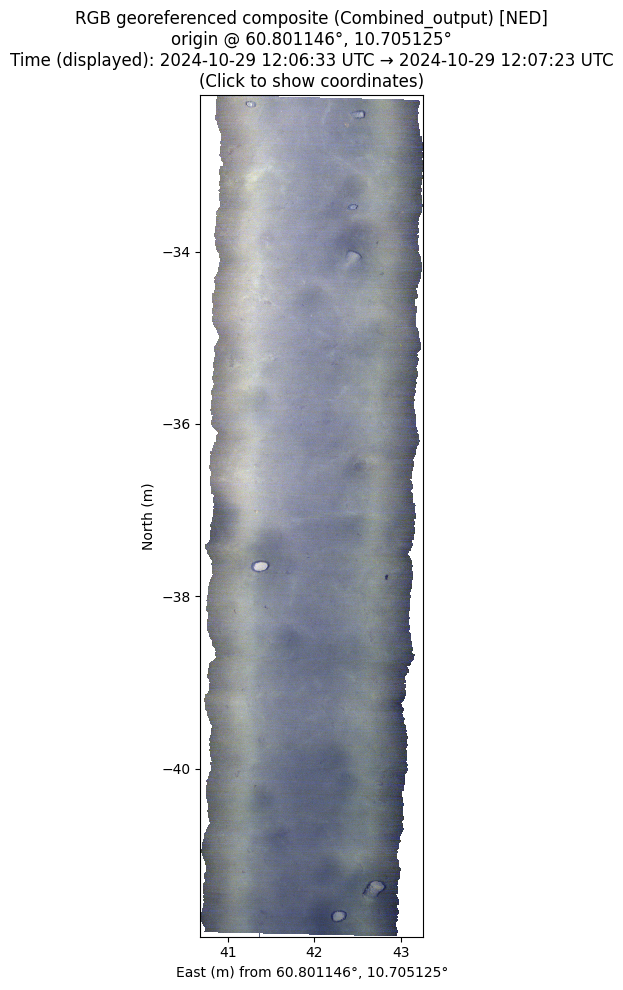

In [4]:
cube.plot_georef(
    use_corrected=False,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
)


🔧 Interpolating 3 wavelength(s):
   • Index 35: 440.31 nm
   • Index 104: 559.97 nm
   • Index 157: 654.20 nm



c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py:5348: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


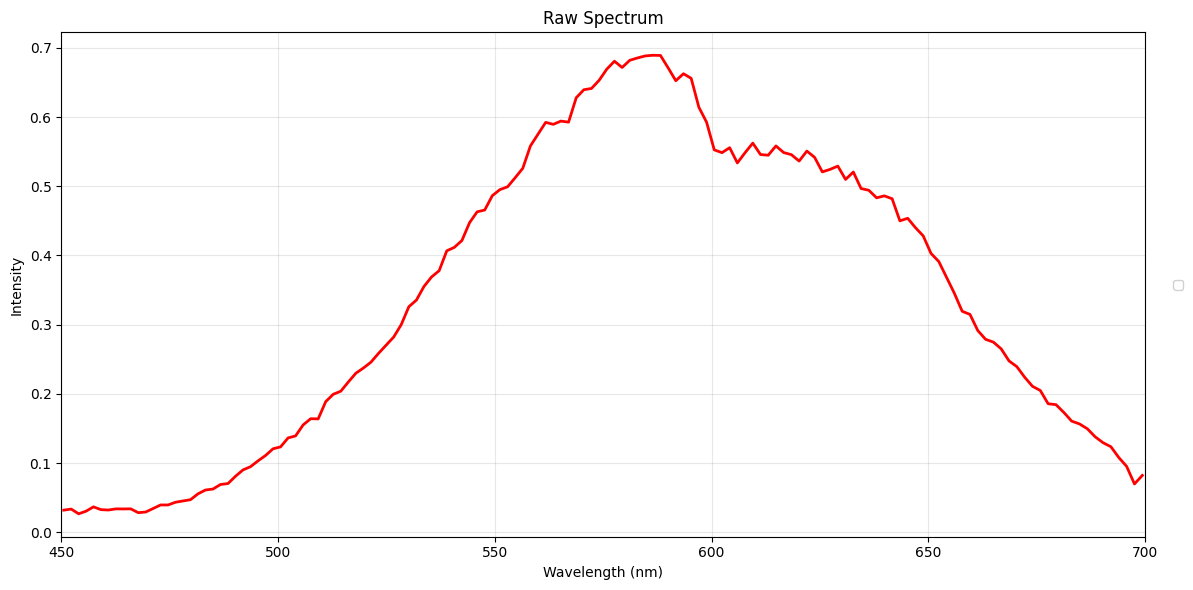

In [5]:
cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(450, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=300,
    # wavelength_smoothing=20,
    interpolate_wavelengths=[35, 104, 157],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)

In [6]:
# cube.plot_georef(
#     use_corrected=True,
#     coordinate_system="NED",
#     track_start=config.UHI_TRACK_RANGE_5[0],
#     track_end=config.UHI_TRACK_RANGE_5[1],
#     contrast_stretch=2.0,  # NEW: 2% linear stretch for better contrast
#     figsize=(30, 10),
# )

## 📊 Corrected Georeferenced RGB with Contrast Enhancement

Plotting the illumination-corrected data with **2% linear stretch** for improved contrast.

**What is Linear 2% Stretch?**
- Clips the darkest 2% and brightest 2% of pixel values
- Stretches the remaining range to use full display range [0, 1]
- Makes features more visible by ignoring extreme outliers
- Common values: `1.0` (subtle), `2.0` (standard), `5.0` (aggressive)

### Compare: Without vs With Contrast Stretch

💡 Interactive mode: Click on the plot to display coordinates


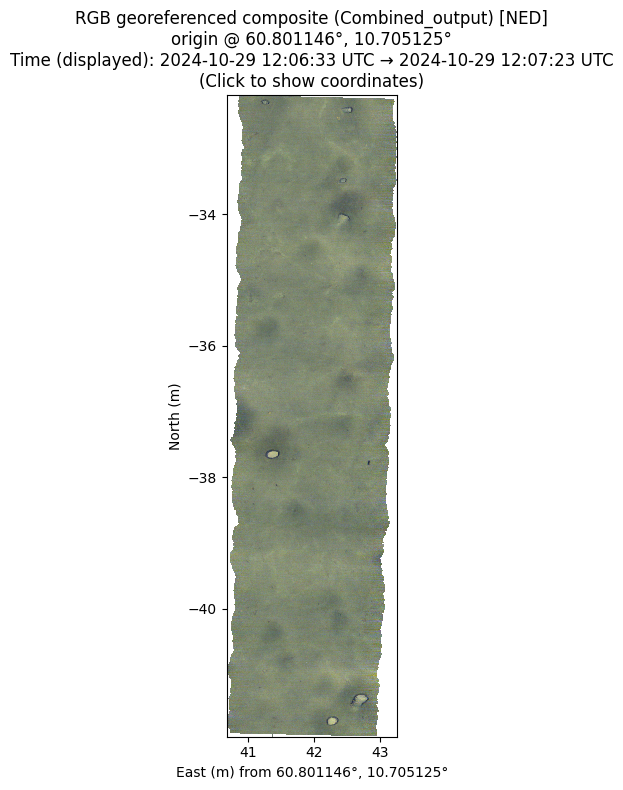

In [7]:
# WITHOUT contrast stretch (default)
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(20, 8),
)

💡 Interactive mode: Click on the plot to display coordinates


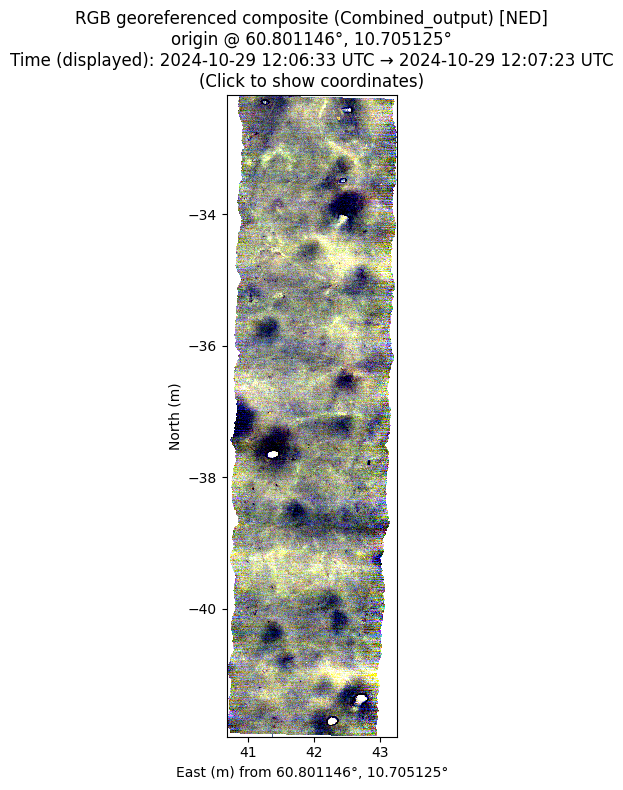

In [8]:
# WITH 2% linear contrast stretch
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    contrast_stretch=2.0,  # 2% stretch (standard)
    figsize=(20, 8),
)

In [9]:
%matplotlib inline

# full corrected spectrum


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py:5348: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


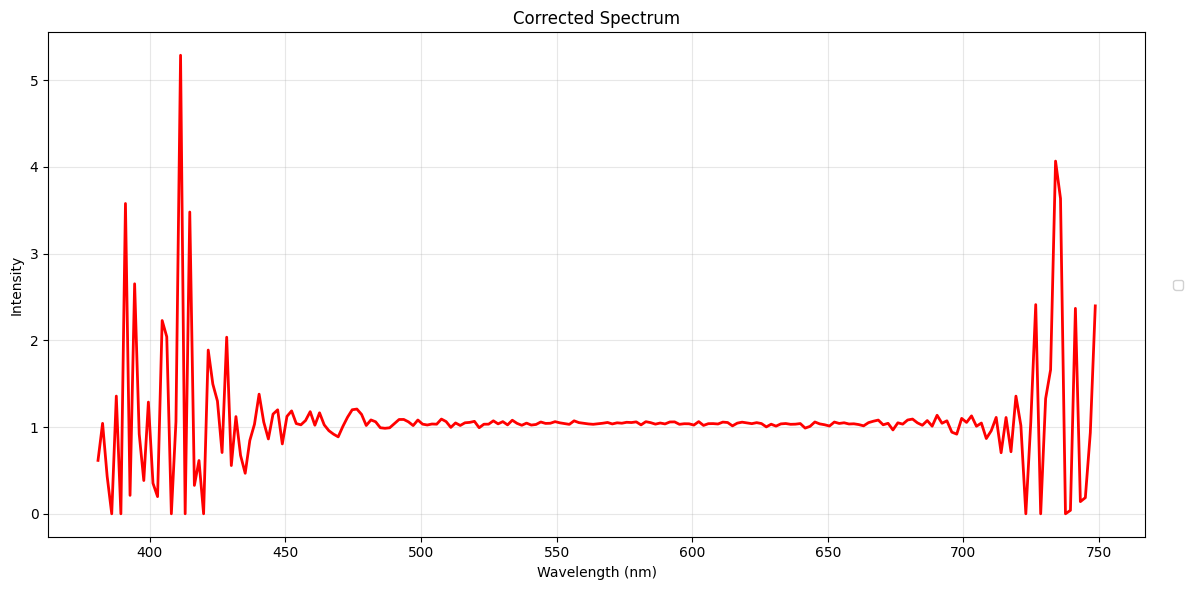

In [10]:
cube.plot_spectrum(
    use_corrected=True,
    # wavelength_range=(450, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    # wavelength_smoothing=2,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)

# with moving window filtering


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



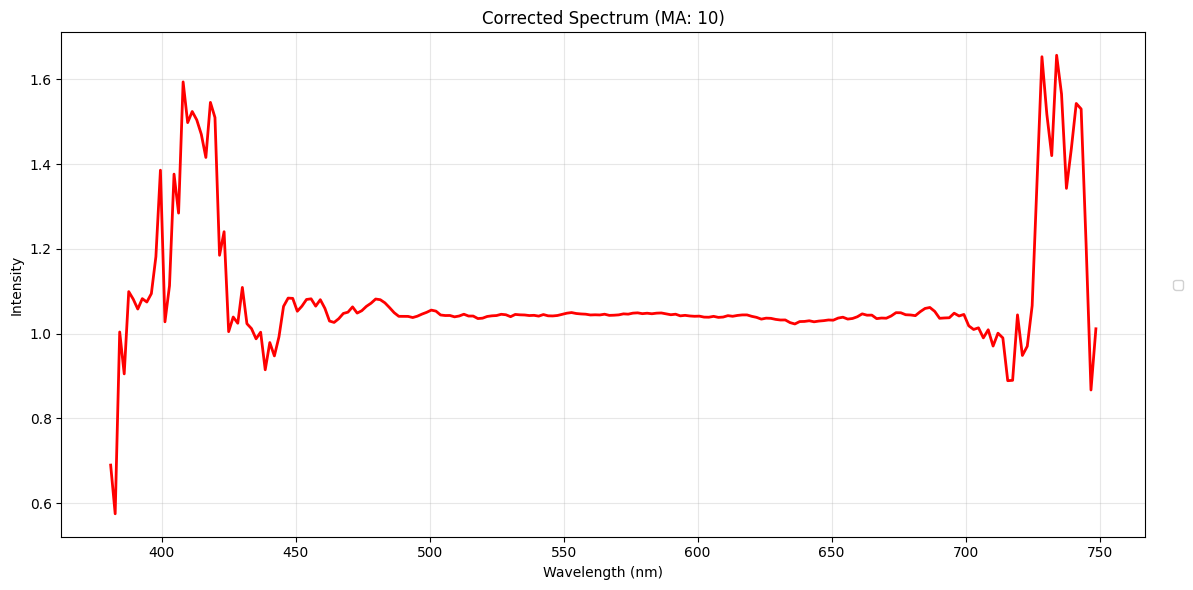

In [11]:
cube.plot_spectrum(
    use_corrected=True,
    # wavelength_range=(450, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=10,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



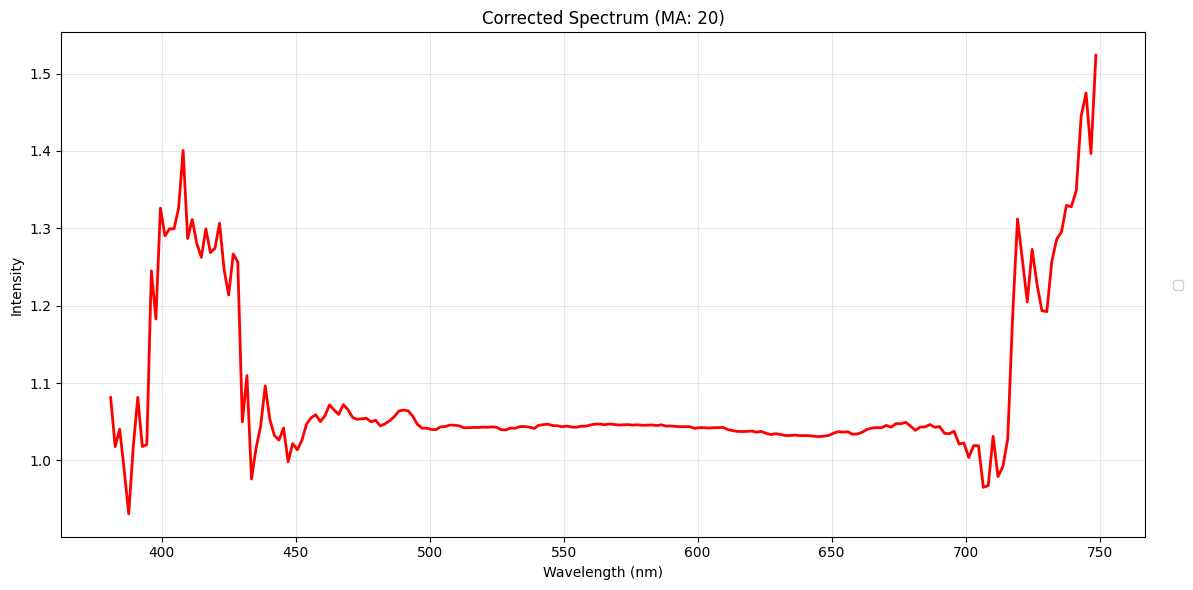

In [12]:
cube.plot_spectrum(
    use_corrected=True,
    # wavelength_range=(450, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=20,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
)

# savrol


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py:5348: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


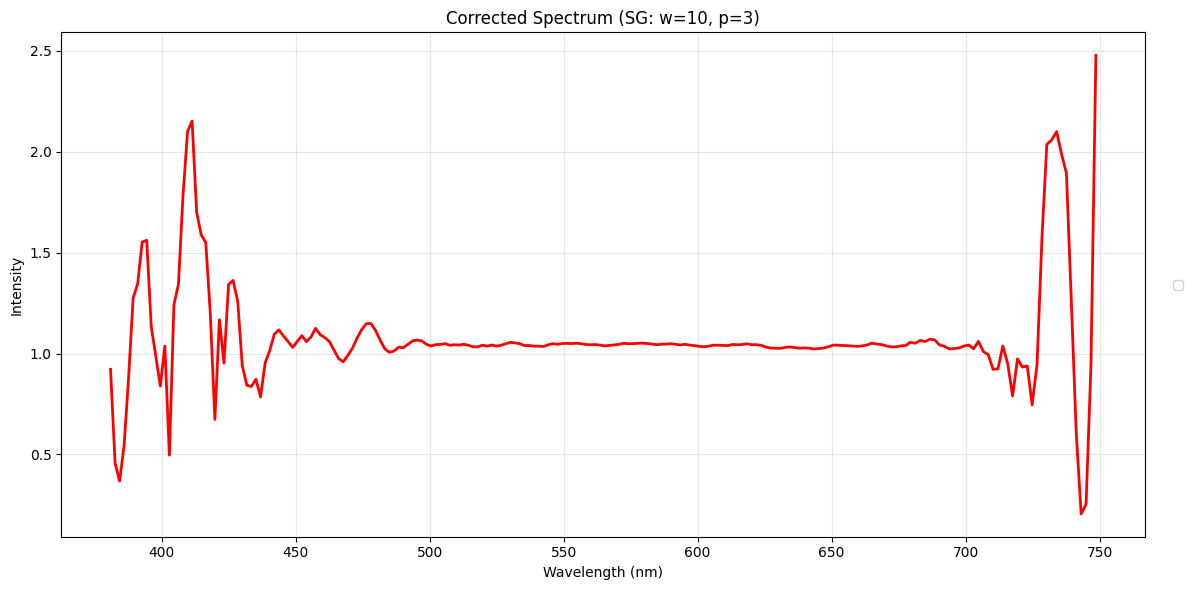

In [13]:
cube.plot_spectrum(
    use_corrected=True,
    # wavelength_range=(450, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=10,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    smoothing_method="savgol",
    savgol_polyorder=3,
    show_std=False,
)


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



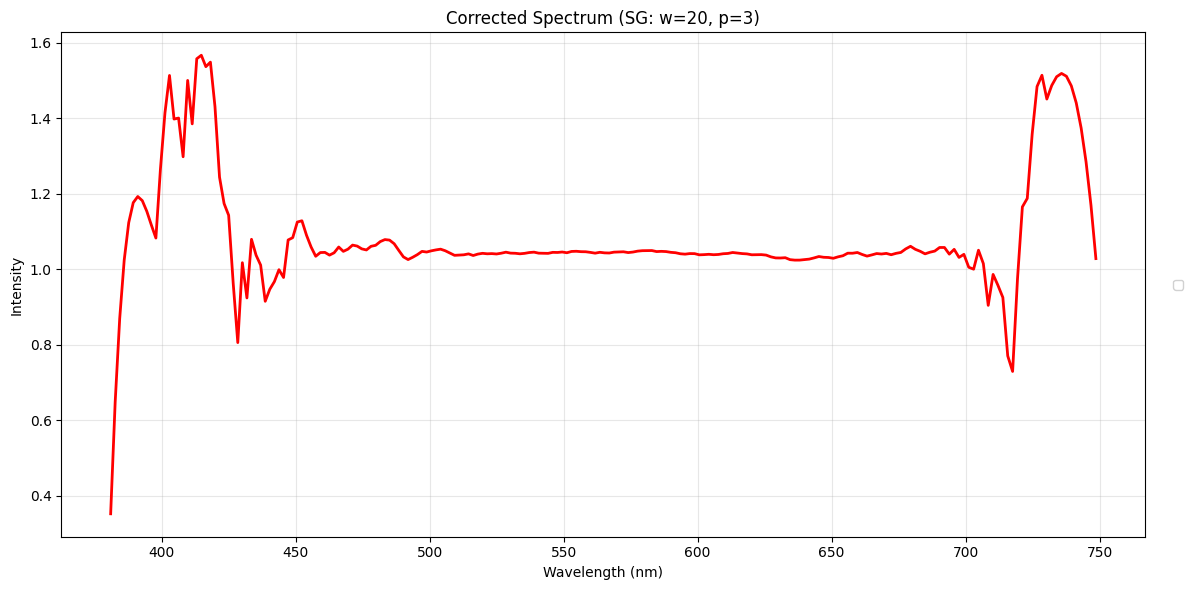

In [14]:
cube.plot_spectrum(
    use_corrected=True,
    # wavelength_range=(450, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=20,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
    smoothing_method="savgol",
    savgol_polyorder=3,
)

# same as above but zoomed in


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



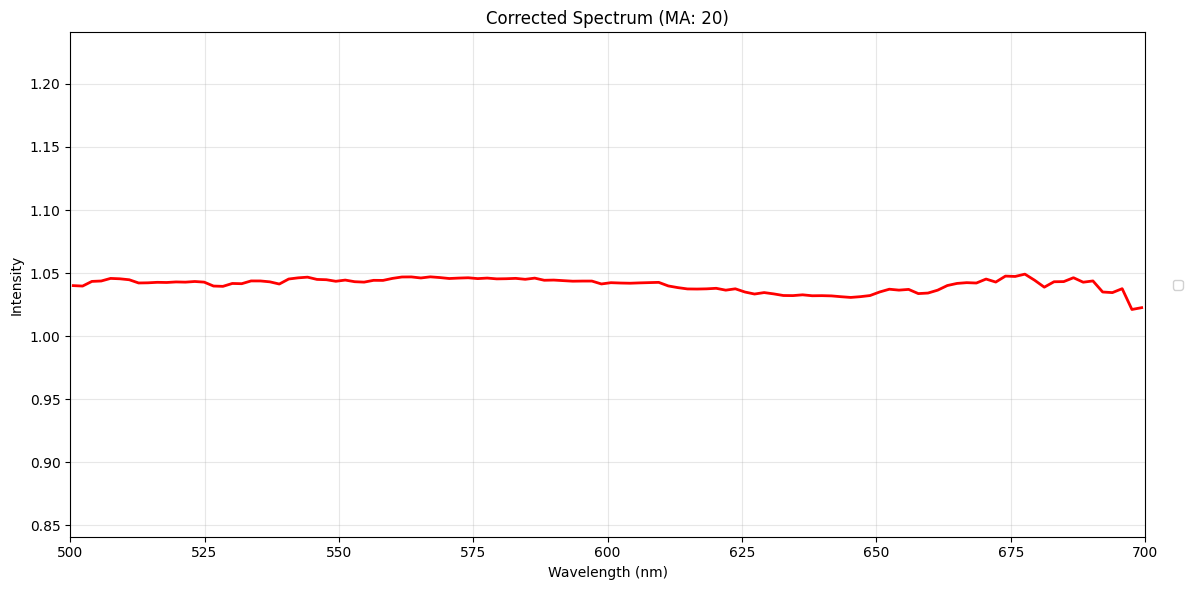

In [15]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=20,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
    smooth_before_filter=True,
    ylim=0.2,
)


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



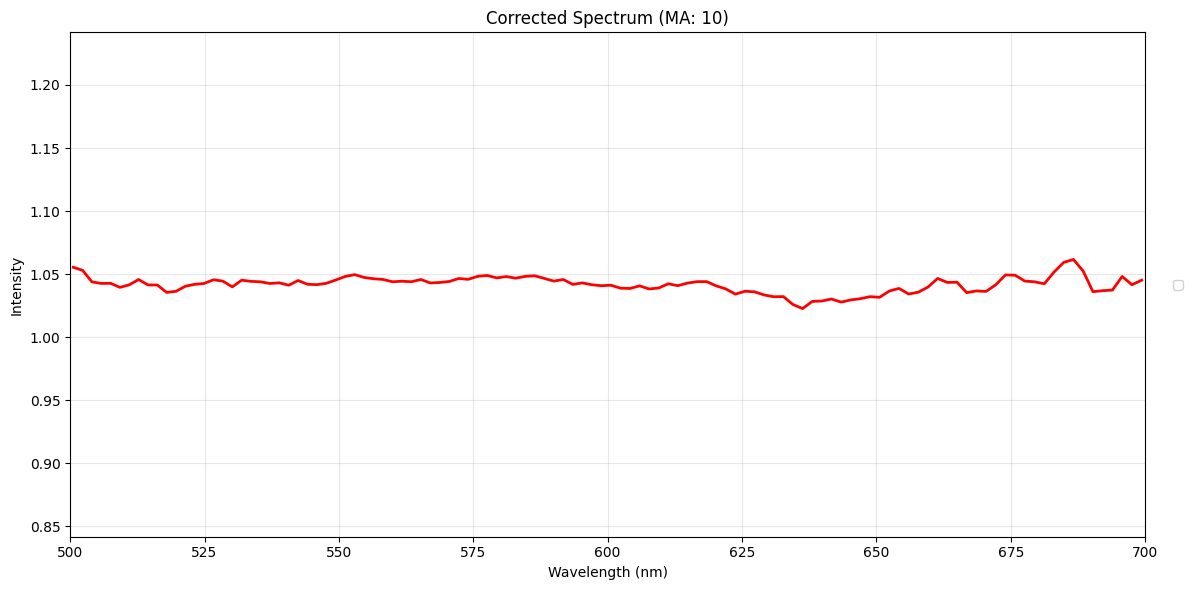

In [16]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=10,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
    smooth_before_filter=True,
    ylim=0.2,
)

# zoomed in for savrol


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



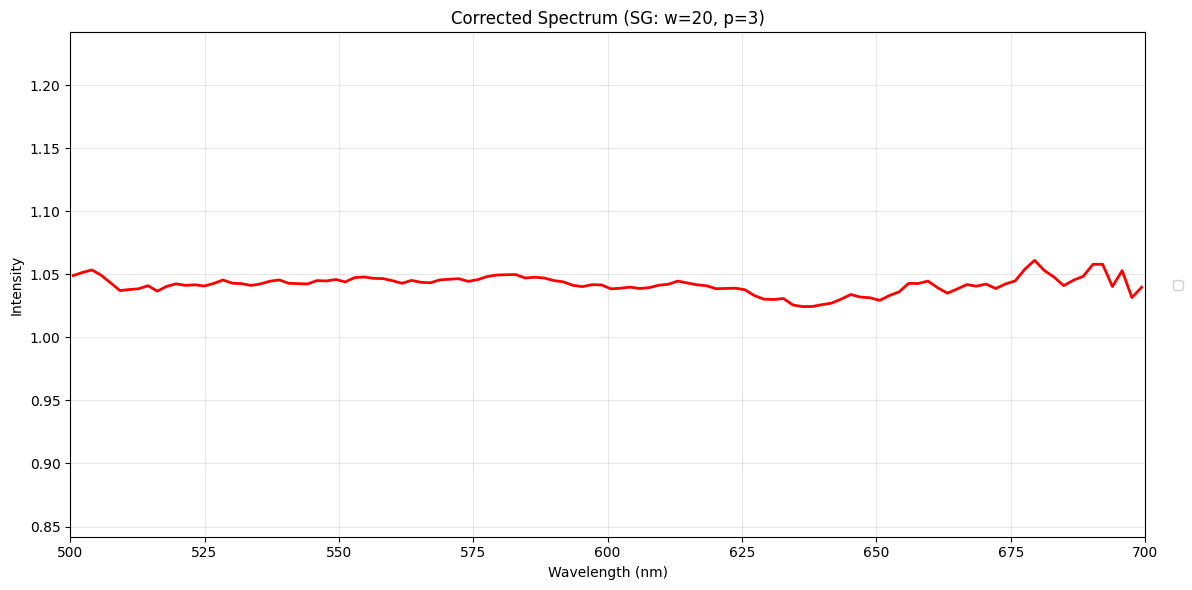

In [17]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=20,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    smoothing_method="savgol",
    savgol_polyorder=3,
    show_std=False,
    smooth_before_filter=True,
    ylim=0.2,
)


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



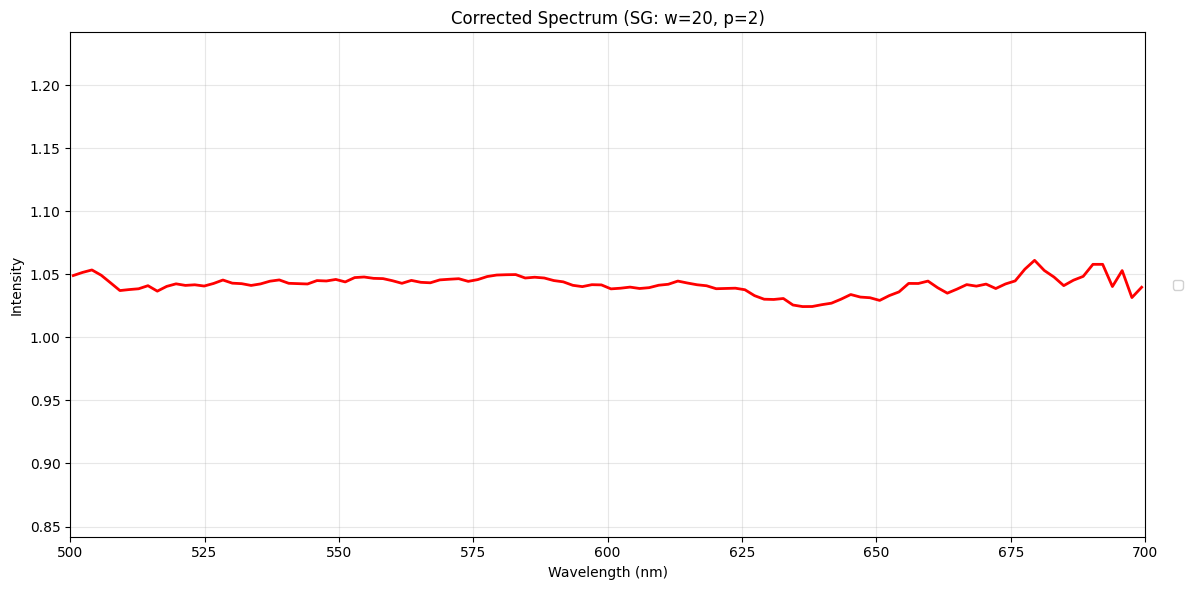

In [18]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=20,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    smoothing_method="savgol",
    savgol_polyorder=2,
    show_std=False,
    smooth_before_filter=True,
    ylim=0.2,
)

# smooth after filtering


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



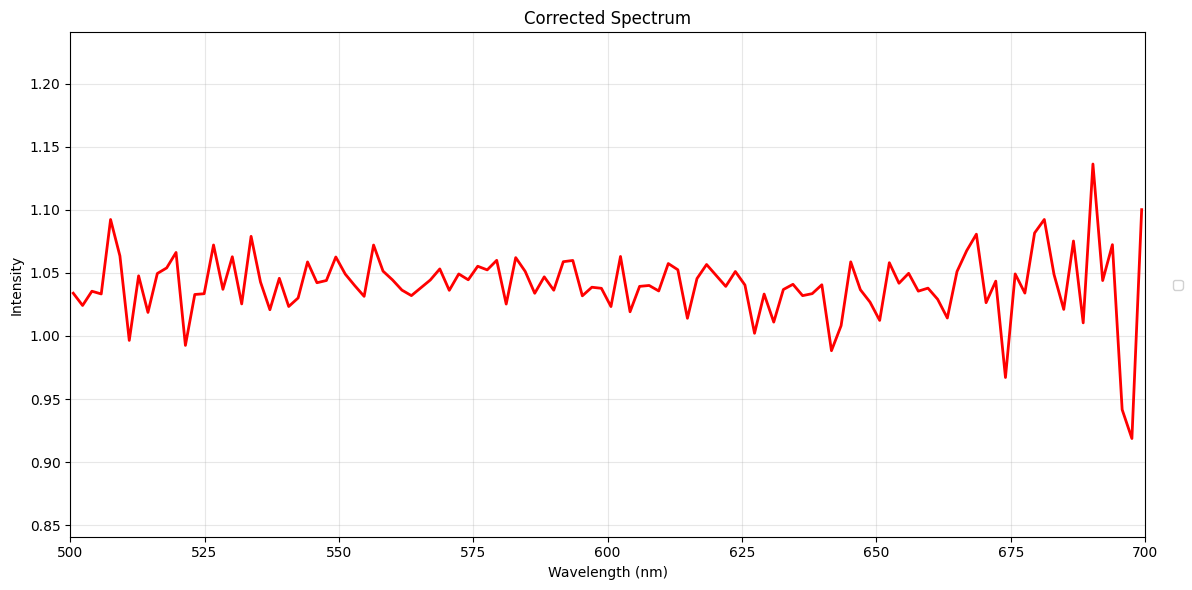

In [19]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    # wavelength_smoothing=10,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
    smooth_before_filter=False,
    ylim=0.2,
)


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



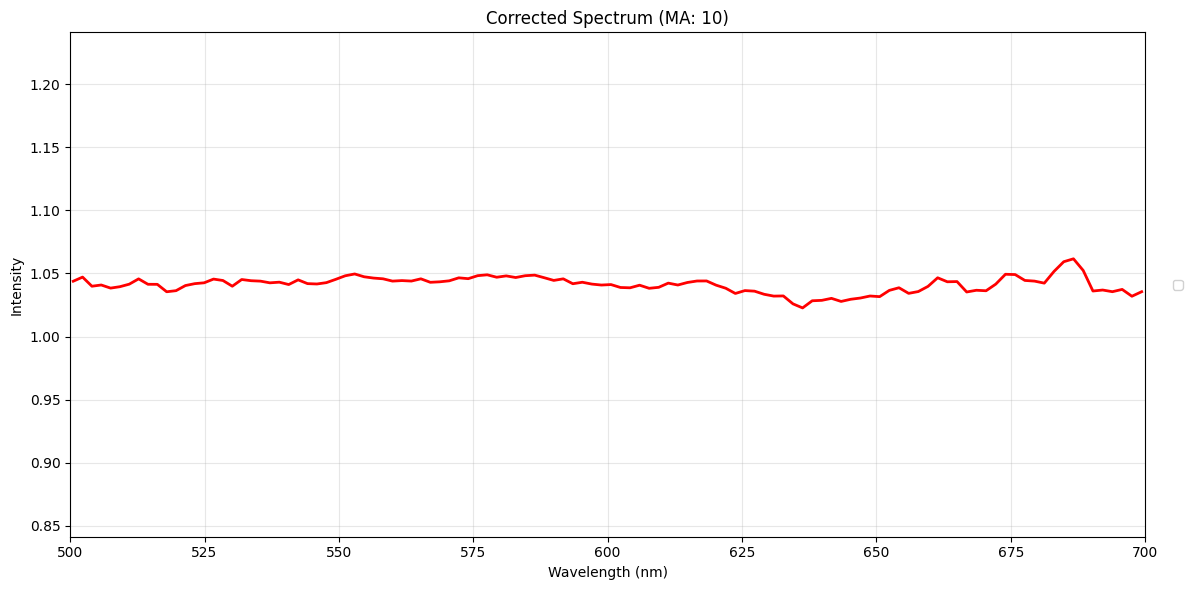

In [20]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=10,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
    smooth_before_filter=False,
    ylim=0.2,
)


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



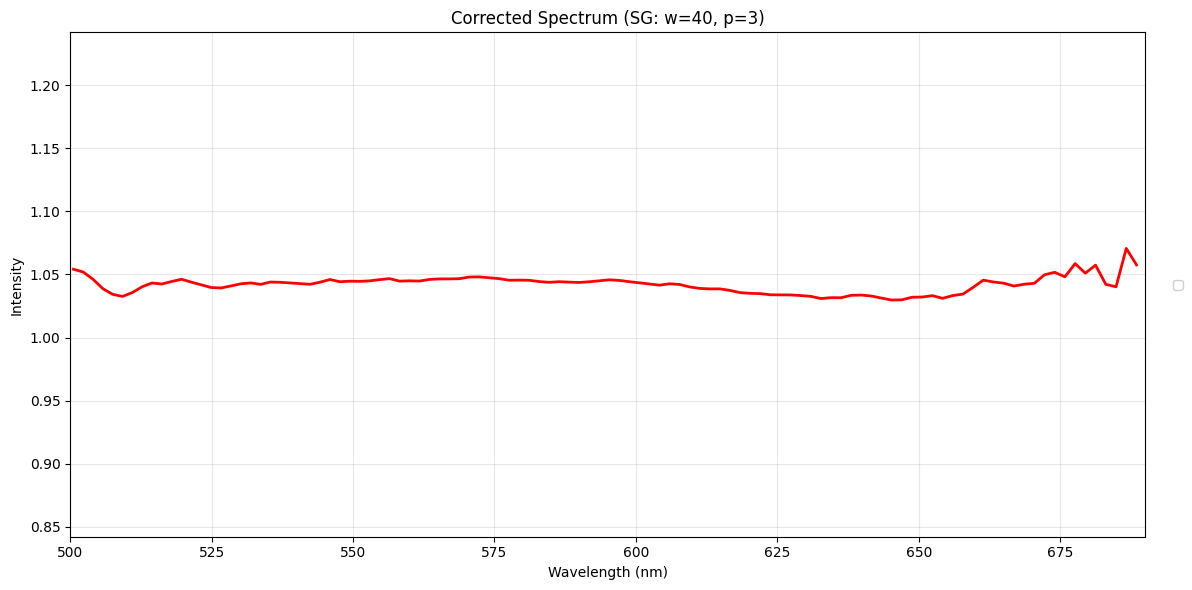

In [21]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 690),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=40,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=False,
    smooth_before_filter=True,
    ylim=0.2,
    smoothing_method="savgol",
    savgol_polyorder=3,
)

# now for savrol


🔧 Interpolating 3 wavelength(s):
   • Index 64: 490.18 nm
   • Index 107: 565.25 nm
   • Index 138: 620.19 nm



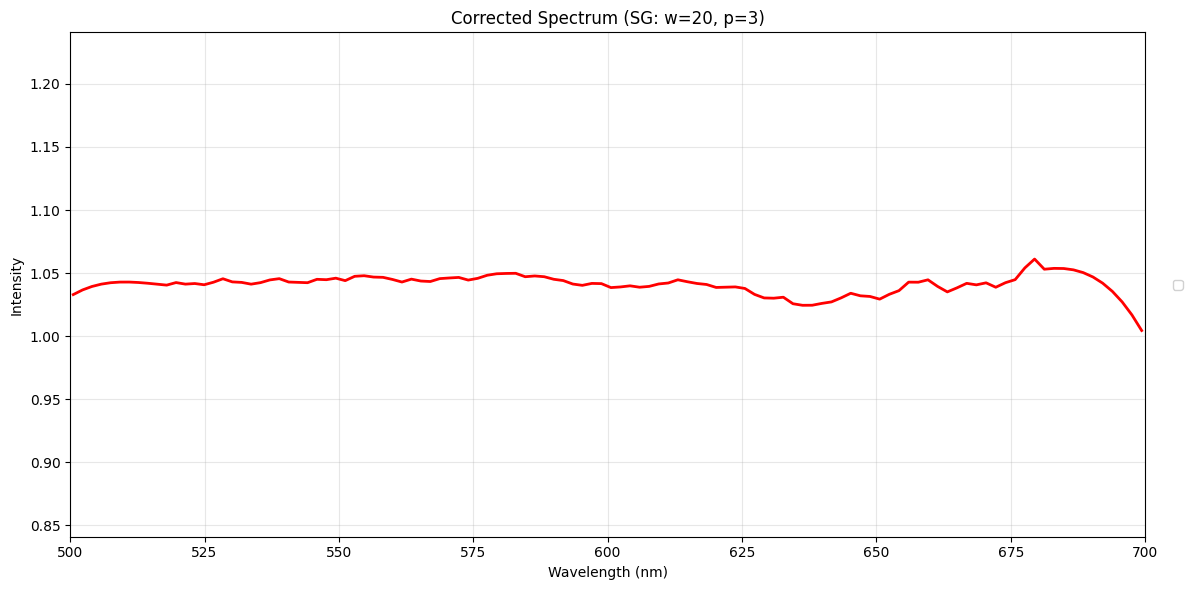

In [22]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(500, 700),
    track_index=config.UHI_TRACK_RANGE_5[0] + 100,
    slit_index=351,
    wavelength_smoothing=20,
    # interpolate_wavelengths=[80, 104, 157],
    # interpolate_wavelengths=[35, 104, 157],
    interpolate_wavelengths=[64, 107, 138],
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    smoothing_method="savgol",
    savgol_polyorder=3,
    show_std=False,
    smooth_before_filter=False,
    ylim=0.2,
)

## 🔍 Check: How many wavelengths are in the 500-700nm range?

In [23]:
# Check wavelength spacing and count in range
wavelengths = cube.wavelengths
wl_in_range = wavelengths[(wavelengths >= 500) & (wavelengths <= 700)]

print(f"Total wavelengths: {len(wavelengths)}")
print(f"Wavelengths in 500-700nm range: {len(wl_in_range)}")
print(f"Wavelength spacing: {np.mean(np.diff(wavelengths)):.2f} nm")
print(f"\nFirst few wavelengths in range: {wl_in_range[:5]}")
print(f"Last few wavelengths in range: {wl_in_range[-5:]}")
print(
    f"\nWith window_size=10, you're averaging over ~{10 * np.mean(np.diff(wavelengths)):.1f} nm"
)

Total wavelengths: 210
Wavelengths in 500-700nm range: 113
Wavelength spacing: 1.76 nm

First few wavelengths in range: [500.5763  502.31125 504.04688 505.78326 507.52042]
Last few wavelengths in range: [692.0972  693.90967 695.7228  697.5367  699.3513 ]

With window_size=10, you're averaging over ~17.6 nm


In [24]:
stop

NameError: name 'stop' is not defined

## 💾 Save Pseudo-Reflectance Datacube

Process and save the pseudo-reflectance datacube with interpolation and smoothing.

In [ ]:
# Save pseudo-reflectance with interpolation and smoothing
# Processing: Illumination Correction → Segment Extraction → Interpolation → Smoothing → Save

pseudo_refl = cube.save_as_pseudo_reflectance(
    interpolate_wavelengths=[64, 107, 138],  # Bad wavelength indices to interpolate
    wavelength_smoothing=10,  # Smooth over 10 wavelengths (1 = no smoothing)
    smoothing_method="moving_average",  # NEW: 'moving_average' or 'savgol'
    track_start=config.UHI_TRACK_RANGE_5[0],  # NEW: Start of segment
    track_end=config.UHI_TRACK_RANGE_5[1],  # NEW: End of segment (same as plot_georef)
    overwrite=False,  # Set to True to recalculate if already exists
)

✅ Pseudo-reflectance already exists in all files
   Use overwrite=True to recalculate


## 🆕 NEW: Normalized Pseudo-Reflectance Datacubes!

You can now save **normalized** datacubes for ML/classification! 

**New `normalize_method` parameter** supports all the same methods as `plot_spectrum`:
- `"mean"`: Divide by mean (simple scaling)
- `"mean_center"`: Subtract mean (removes DC offset) ⭐ Good for comparison
- `"snv"`: Standard Normal Variate ⭐ Good for ML/SVM
- `"msc"`: Multiplicative Scatter Correction
- `"minmax"`: Min-max scaling to [0,1]
- `"l2"`: L2 vector normalization

**Saves to a different dataset**: `dataCube_normalized_pseudo_reflectance`


In [ ]:
# Save NORMALIZED pseudo-reflectance for ML/SVM
# Processing: Illumination Correction → Segment → Interpolation → Smoothing → Normalization → Save

normalized_refl = cube.save_as_pseudo_reflectance(
    interpolate_wavelengths=[64, 107, 138],
    wavelength_smoothing=10,
    # smoothing_method="savgol",
    # savgol_polyorder=2,
    smoothing_method="moving_average",  # NEW: 'moving_average' or 'savgol'
    normalize_method="l2",  # 🆕 NEW: Apply normalization!
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    overwrite=False,
)

🔄 CREATING PSEUDO-REFLECTANCE DATACUBE
   Pipeline: Segment Extraction → Interpolation → Smoothing → Normalization → Save
   📏 Segment: tracks 576 to 1566 (length=990)

   🔧 Interpolating 3 wavelength(s):
      • Index 64: 490.18 nm
      • Index 107: 565.25 nm
      • Index 138: 620.19 nm
   🔧 Wavelength smoothing: moving_average (window=10)
   🔧 Normalization: l2

   Step 1/2: Interpolating bad wavelengths...
      ✓ Interpolated 3 wavelength(s)
   Step 2/2: Smoothing wavelengths (MA, window=10)...
      ✓ Smoothing complete
   Step 3/3: Normalizing spectra (l2)...
      ✓ Normalization complete

   💾 Saving to HDF5 files...
      ✓ rad_uhi_20241029_115057_5: (990, 968, 210) (tracks 576 to 1566)

✅ PSEUDO-REFLECTANCE SAVED
   Dataset: processed/radiance/dataCube_normalized_pseudo_reflectance
   Shape: (990, 968, 210)
   Files saved: 1/1
   Segment: tracks 576 to 1566


# plot to check new psuedo reflectance datacubes

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   📦 Loading custom datacube: dataCube_normalized_pseudo_reflectance
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   📦 Loading custom datacube: dataCube_normalized_pseudo_reflectance
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded custom datacube 'dataCube_normalized_pseudo_reflectance': (990, 968, 210) (T × S × B)
✅ Loaded custom datacube 'dataCube_normalized_pseudo_reflectance': (990, 968, 210) (T × S × B)


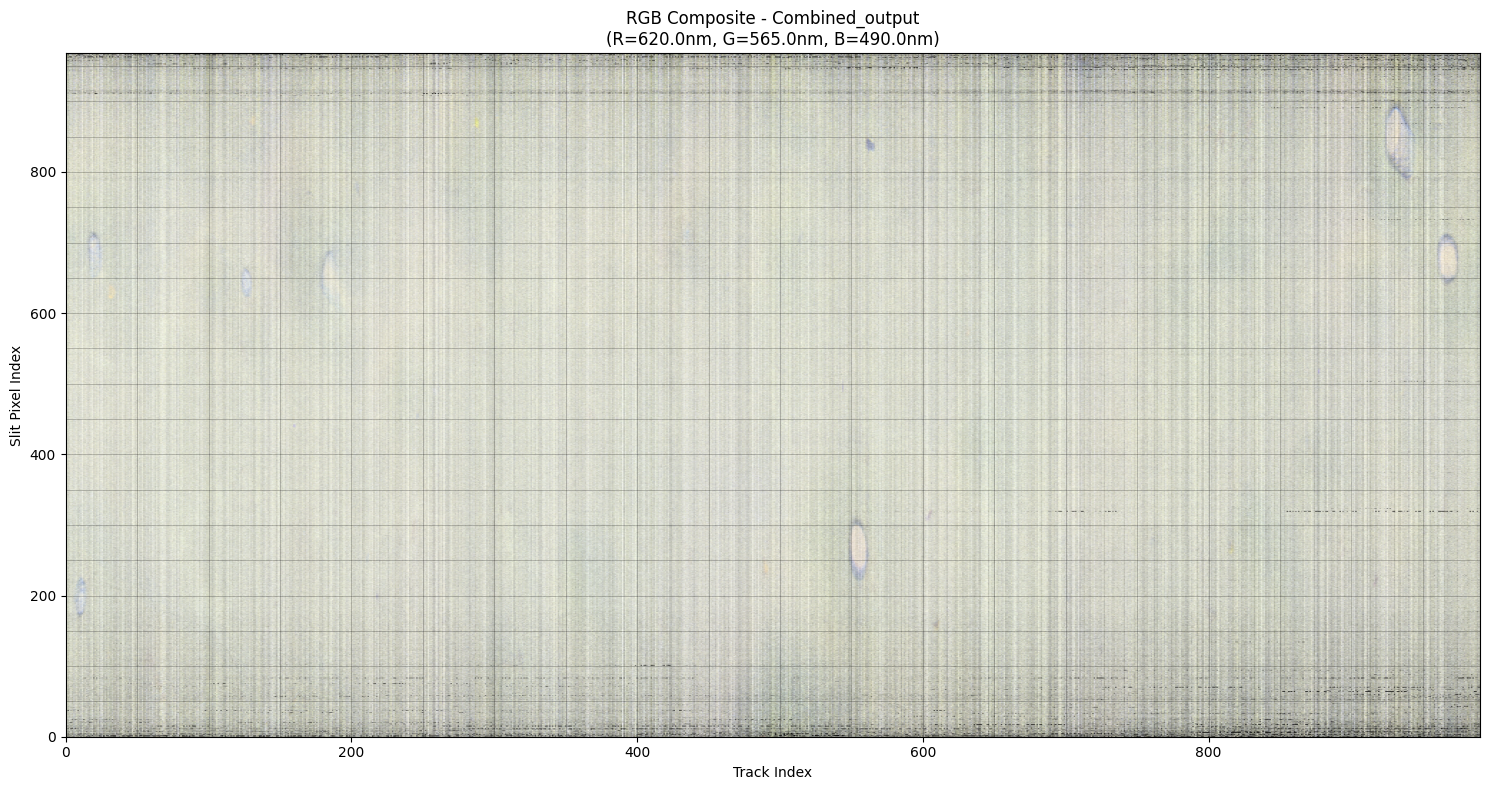

In [25]:
# Example 2: Load NORMALIZED pseudo-reflectance datacube
cube_normalized = transect.select_files(
    ["rad_uhi_20241029_115057_5"],
    load_datacube="dataCube_normalized_pseudo_reflectance",  # Load normalized datacube
)

# Plot the normalized data
cube_normalized.plot_rgb(
    red_wl=620.0,
    green_wl=565.0,
    blue_wl=490.0,
    normalize=True,
    figsize=(15, 8),
)

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   📦 Loading custom datacube: dataCube_pseudo_reflectance
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   📦 Loading custom datacube: dataCube_pseudo_reflectance
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded custom datacube 'dataCube_pseudo_reflectance': (990, 968, 210) (T × S × B)
✅ Loaded custom datacube 'dataCube_pseudo_reflectance': (990, 968, 210) (T × S × B)


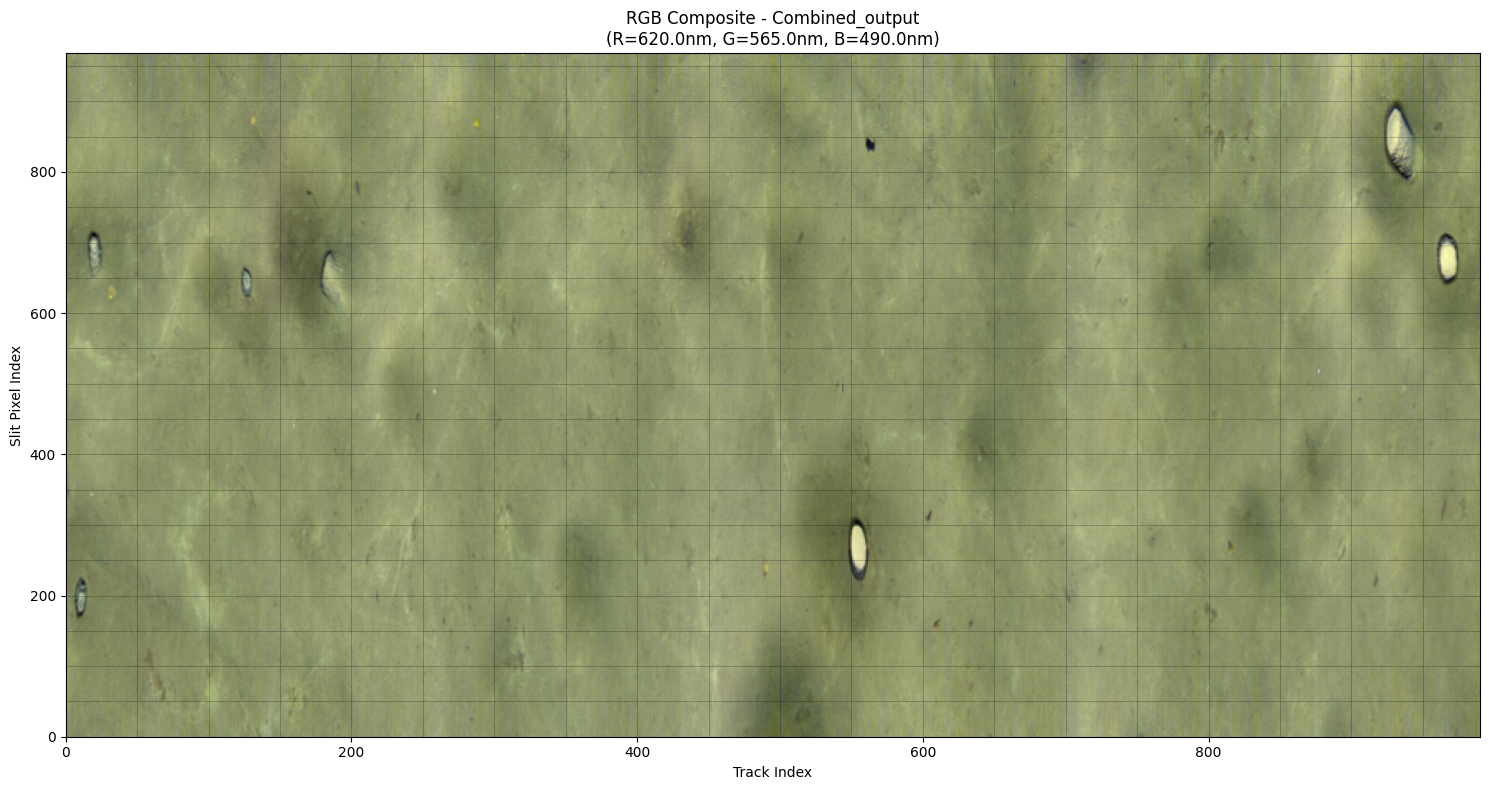

In [26]:
# Example 2: Load NORMALIZED pseudo-reflectance datacube
cube_refl = transect.select_files(
    ["rad_uhi_20241029_115057_5"],
    load_datacube="dataCube_pseudo_reflectance",  # Load pseudo-reflectance datacube
)

# Plot the pseudo-reflectance data
cube_refl.plot_rgb(
    red_wl=620.0,
    green_wl=565.0,
    blue_wl=490.0,
    normalize=True,
    figsize=(15, 8),
)

# lets test to see how the normalization looks at the yellow/green leaf